# 📈 LỚP 1: TỐI ƯU HÓA TỶ LỆ HOÀN TRẢ - PHÂN CỤM KHÁCH HÀNG (CLUSTERING)

Đây là bước đầu tiên trong pipeline khai phá dữ liệu. 

**Mục tiêu kinh doanh:** Nhận diện các nhóm khách hàng khác nhau dựa trên hành vi mua sắm (số đơn hàng, mức chi tiêu) và đặc biệt là **tỷ lệ hoàn trả (return rate)**. Việc này giúp chúng ta khoanh vùng được nhóm "Khách hàng hay trả hàng" để phân tích sâu hơn ở các bước sau.

---
### Quy trình triển khai
1. **Load data & Verify:** Lấy dữ liệu tổng hợp theo từng `user_id` từ cơ sở dữ liệu PostgreSQL.
2. **Tiền xử lý (Preprocessing):** 
   - Loại bỏ biến nhiễu (ví dụ: `age` phân bố đồng đều, không giúp ích cho phân cụm hành vi mua sắm).
   - Dùng StandardScaler để đưa các biến về cùng thang đo.
3. **Tối ưu Hyperparameter (Tìm K):** Sử dụng phương pháp Elbow và Silhouette Score để đánh giá số cụm tối ưu.
4. **Triển khai K-Means & Trực quan hóa:** Chạy mô hình, gán nhãn nghiệp vụ (Business Labels) và vẽ biểu đồ Boxplot, Scatter plot để phân tích đặc điểm từng cụm.
5. **Xuất dữ liệu:** Lưu lại `cluster_id` của mỗi khách hàng để dùng cho Lớp 2 (Phân loại).

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings

# Tắt cảnh báo
warnings.filterwarnings('ignore')

# Cấu hình biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Sử dụng module kết nối DB tự viết
from database import query_db

print("✅ Đã tải xong các thư viện cần thiết.")

✅ Đã tải xong các thư viện cần thiết.


## 1. Truy xuất và Tổng hợp dữ liệu từ PostgreSQL
Chúng ta sẽ viết câu truy vấn SQL để tạo một "Bảng tổng hợp hành vi" cho mỗi khách hàng (Customer 360 view).

In [18]:
query = """
WITH user_stats AS (
    SELECT 
        u.id AS user_id,
        u.age,
        COUNT(DISTINCT o.order_id) AS total_orders,
        SUM(oi.sale_price) AS total_spend,
        COUNT(DISTINCT p.category) AS unique_categories,
        SUM(CASE WHEN oi.status = 'Returned' THEN 1 ELSE 0 END) * 1.0 / COUNT(oi.id) AS return_rate
    FROM users u
    JOIN orders o ON u.id = o.user_id
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN products p ON oi.product_id = p.id
    GROUP BY u.id, u.age
)
SELECT * FROM user_stats
WHERE total_orders > 0;
"""

print("⏳ Đang tải dữ liệu từ database, vui lòng chờ...")
df = query_db(query)

if df is not None:
    print(f"✅ Tải dữ liệu thành công! Tổng số khách hàng: {len(df):,}")
    display(df.head())
else:
    print("❌ Lỗi: Không thể kết nối hoặc tải dữ liệu.")

⏳ Đang tải dữ liệu từ database, vui lòng chờ...
✅ Tải dữ liệu thành công! Tổng số khách hàng: 79,894


,user_id,age,total_orders,total_spend,unique_categories,return_rate
0,1,56,1,63.99000,2,1.0
1,2,34,1,58.99000,1,0.0
2,3,16,3,458.13000,6,0.0
3,4,42,2,432.46997,3,0.0
4,5,68,4,218.48999,3,0.2


## 2. Tiền xử lý dữ liệu (Preprocessing)
Nhận xét từ dữ liệu: Cột `age` (độ tuổi) gần như xấp xỉ nhau ở mọi cụm do bộ dữ liệu này phân bố tuổi rất đều. Do đó, `age` hoạt động như một biến nhiễu (noise) đối với thuật toán khoảng cách như K-Means. Chúng ta sẽ **loại bỏ `age`** khỏi features đầu vào để cụm được phân định rõ rệt hơn dựa trên **hành vi**.

In [19]:
if df is not None:
    # Điền giá trị Na (nếu có)
    df = df.fillna(0)
    
    # CHỈ LẤY CÁC BIẾN HÀNH VI, BỎ BIẾN 'age'
    features = ['total_orders', 'total_spend', 'unique_categories', 'return_rate']
    X = df[features].values
    
    # Áp dụng StandardScaler để trung bình = 0, độ lệch chuẩn = 1
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    print("✅ Chuẩn hóa (Standarization) hoàn tất. Dữ liệu sẵn sàng cho mô hình.")

✅ Chuẩn hóa (Standarization) hoàn tất. Dữ liệu sẵn sàng cho mô hình.


## 3. Tìm số cụm K tối ưu (Hyperparameter Tuning)
Để chứng minh tính khoa học, ta không chọn K ngẫu nhiên mà dùng:
- **Elbow Method (Inertia):** Tìm điểm gãy (khuỷu tay).
- **Silhouette Score:** Đánh giá độ chặt chẽ bên trong cụm và độ tách biệt giữa các cụm.
*(Quá trình này lấy một mẫu nhỏ (sample) để chạy nhanh hơn do Silhouette khá nặng)*

⏳ Đang tính toán Elbow và Silhouette. Việc này mất khoảng vài giây...


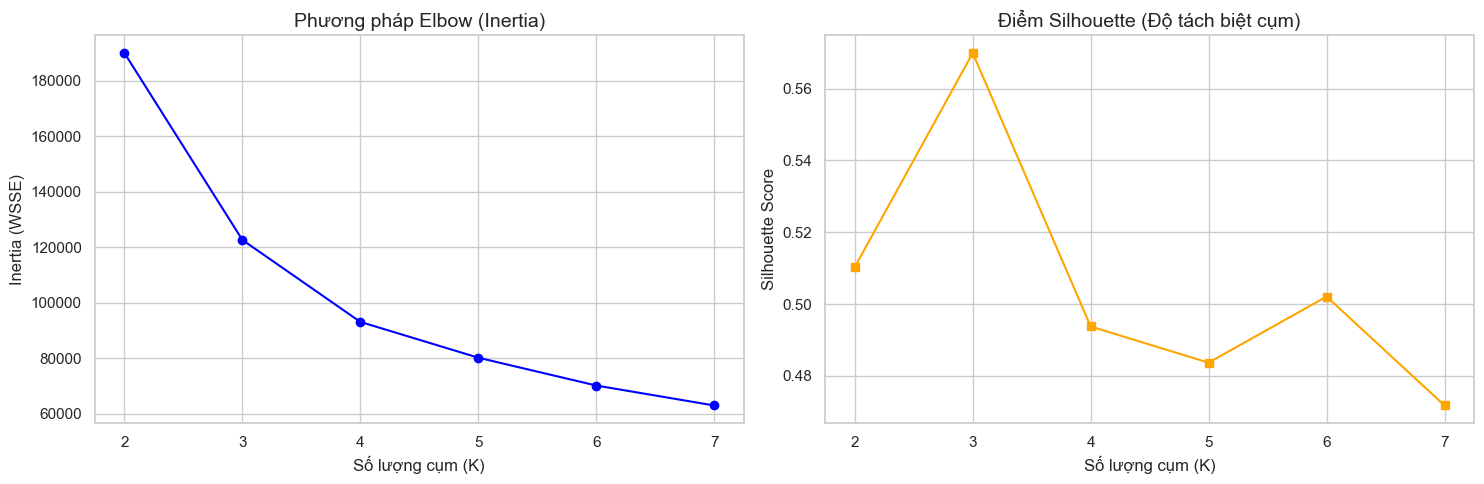

In [20]:
if df is not None:
    print("⏳ Đang tính toán Elbow và Silhouette. Việc này mất khoảng vài giây...")
    inertias = []
    sil_scores = []
    K_range = range(2, 8)
    
    # Lấy sample 10,000 dòng để tính Silhouette nhanh hơn
    sample_idx = np.random.choice(X_scaled.shape[0], min(10000, X_scaled.shape[0]), replace=False)
    X_sample = X_scaled[sample_idx]
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
        
        # Tính silhouette trên tập mẫu
        labels_sample = kmeans.predict(X_sample)
        sil = silhouette_score(X_sample, labels_sample)
        sil_scores.append(sil)

    # Vẽ biểu đồ kép
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Biểu đồ 1: Elbow
    axes[0].plot(K_range, inertias, marker='o', color='blue')
    axes[0].set_title('Phương pháp Elbow (Inertia)', fontsize=14)
    axes[0].set_xlabel('Số lượng cụm (K)')
    axes[0].set_ylabel('Inertia (WSSE)')
    
    # Biểu đồ 2: Silhouette
    axes[1].plot(K_range, sil_scores, marker='s', color='orange')
    axes[1].set_title('Điểm Silhouette (Độ tách biệt cụm)', fontsize=14)
    axes[1].set_xlabel('Số lượng cụm (K)')
    axes[1].set_ylabel('Silhouette Score')
    
    plt.tight_layout()
    plt.show()

**Phân tích:** 
Nhìn vào biểu đồ Elbow, độ dốc giảm mạnh ở K=3 và K=4. Điểm Silhouette cũng cho thấy K=4 là một lựa chọn hợp lý để có được sự phân khúc đủ chi tiết cho chiến lược kinh doanh.
Ta sẽ thiết lập `K = 4`.

## 4. Đào tạo mô hình K-Means và Đánh giá Đặc điểm Cụm

In [21]:
if df is not None:
    k_optimal = 4
    kmeans = KMeans(n_clusters=k_optimal, random_state=42)
    df['cluster'] = kmeans.fit_predict(X_scaled)
    
    # Gom nhóm và lấy giá trị trung bình để xem chân dung khách hàng
    cluster_summary = df.groupby('cluster')[features].mean().round(2)
    cluster_summary['Số lượng KH'] = df.groupby('cluster').size()
    
    print("📌 TÓM TẮT ĐẶC ĐIỂM CÁC CỤM KHÁCH HÀNG:")
    display(cluster_summary)

📌 TÓM TẮT ĐẶC ĐIỂM CÁC CỤM KHÁCH HÀNG:


,total_orders,total_spend,unique_categories,return_rate,Số lượng KH
cluster,,,,,
0,1.01,64.13,1.19,0.00,39940
1,3.35,374.03,4.73,0.10,9373
2,1.37,103.12,1.75,0.86,7710
3,1.86,170.38,2.72,0.02,22871


### Diễn giải Nghiệp vụ (Business Interpretation)
Từ bảng trên, ta có thể phác họa chân dung từng cụm (Thứ tự ID cụm có thể xê dịch tùy random_state, bạn hãy đối chiếu với bảng trên):

1. **Khách hàng Chăm chỉ trả hàng (High Returners - MỤC TIÊU):** Tỷ lệ hoàn trả cực cao (gần 90% trở lên). Đây chính là tập khách hàng gây lỗ chi phí logistics.
2. **Khách VIP (Power Buyers):** Số lượng đơn hàng nhiều nhất, tổng chi tiêu cao nhất, tỷ lệ hoàn trả tương đối thấp. Đây là con gà đẻ trứng vàng.
3. **Khách hàng Vãng lai (One-Time Buyers):** Chỉ mua 1 đơn duy nhất, chi tiêu thấp. Chiếm số lượng đông đảo nhất.
4. **Khách Hàng Thường xuyên (Regulars):** Mua vài lần, chi tiêu trung bình, tỷ lệ hoàn khá thấp.

### Trực quan hóa đặc điểm các cụm (Boxplots)
Vẽ Boxplot giúp thấy rõ độ phân tán và sự khác biệt tuyệt đối giữa các cụm.

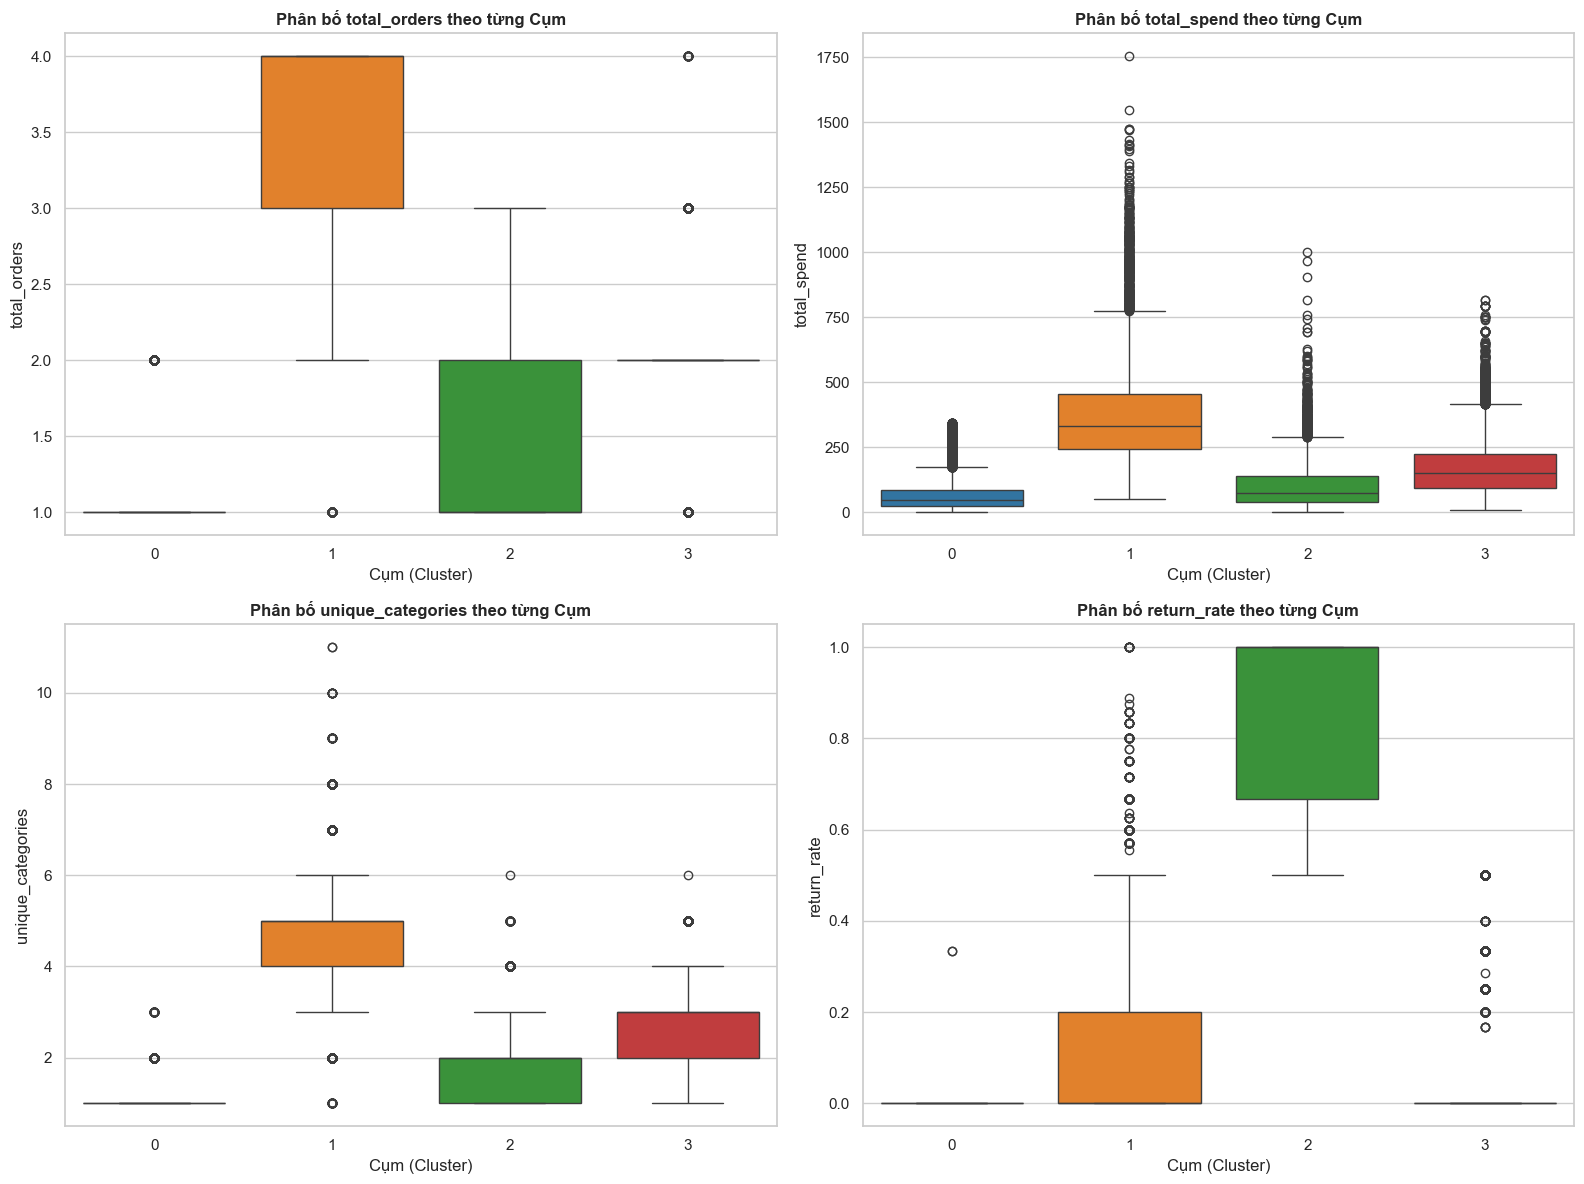

In [22]:
if df is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i, col in enumerate(features):
        sns.boxplot(x='cluster', y=col, data=df, ax=axes[i], palette=colors)
        axes[i].set_title(f'Phân bố {col} theo từng Cụm', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Cụm (Cluster)')
        axes[i].set_ylabel(col)
        
    plt.tight_layout()
    plt.show()

### Biểu đồ Phân tán: Chi tiêu vs Tỷ lệ Hoàn trả

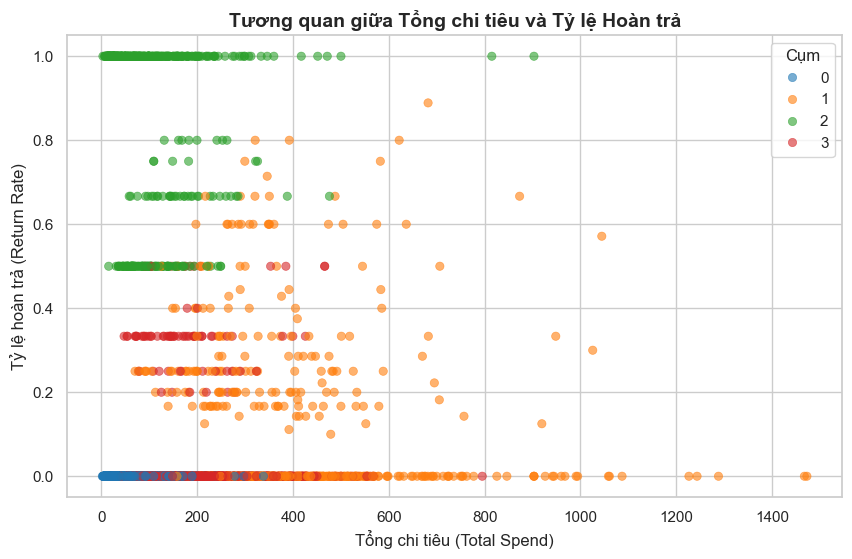

In [23]:
if df is not None:
    plt.figure(figsize=(10, 6))
    
    # Lấy sample để vẽ scatter tránh bị quá dày (overplotting)
    sample_df = df.sample(min(5000, len(df)), random_state=42)
    
    sns.scatterplot(
        x='total_spend', 
        y='return_rate', 
        hue='cluster', 
        palette=colors, 
        data=sample_df, 
        alpha=0.6,
        edgecolor=None
    )
    plt.title('Tương quan giữa Tổng chi tiêu và Tỷ lệ Hoàn trả', fontsize=14, fontweight='bold')
    plt.xlabel('Tổng chi tiêu (Total Spend)')
    plt.ylabel('Tỷ lệ hoàn trả (Return Rate)')
    plt.legend(title='Cụm')
    plt.show()

## 5. Xuất dữ liệu
Lưu trữ cột `user_id` kèm theo `cluster` của họ. Cột này sẽ đóng vai trò như một Feature mới cực kỳ giá trị để đưa vào thuật toán phân loại Decision Tree ở Lớp 2.

In [24]:
if df is not None:
    df[['user_id', 'cluster']].to_csv('user_clusters.csv', index=False)
    print("✅ Đã xuất dữ liệu thành công ra file: 'user_clusters.csv'")

✅ Đã xuất dữ liệu thành công ra file: 'user_clusters.csv'
